# 02 — Random Forest

The **predictive champion** of the project. Random Forest
breaks past Logistic Regression's "linear ceiling" (+1.48%
Acc, +2.73% F1 on Advanced) by exploiting non-linear
feature interactions. Critically, its feature-importance
ranking **inverts** the LR coefficient picture — see README
§3.5.

## 1 — Setup

Configure matplotlib for inline rendering, add the project
root to `sys.path` so we can import from `src/`, and pull in
the shared helpers + the project-wide `RANDOM_STATE = 42`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# `notebooks/` is one level below the project root; add the
# project root so `from src import ...` resolves correctly.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (single source of truth in src.train_utils)")

RANDOM_STATE = 42 (single source of truth in src.train_utils)


## 2 — Load the preprocessed feature matrices

`load_preprocessed()` returns the two parallel matrices
produced by Phase 1: the **Baseline** (nutrition + tags only)
and the **Advanced** (Baseline + 9 engineered culinary
features). Both share the same train/test partition so the
A/B comparison is apples-to-apples.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 — Configure the model

200 trees gives a small bump over the default 100 at
negligible cost; `n_jobs=-1` uses all available cores.
`random_state=RANDOM_STATE` propagates the 42 seed to the
bagging RNG.

In [3]:
from sklearn.ensemble import RandomForestClassifier

MODEL_SLUG    = "random_forest"
MODEL_NAME    = "RandomForest"
DISPLAY_NAME  = "Random Forest"
TOP_K         = 20

MODEL_CONFIG = {
    "n_estimators": 200,
    "n_jobs":       -1,
    "random_state": RANDOM_STATE,
}
MODEL_CONFIG

{'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}

## 4 — Train on both matrices

Each matrix gets a **fresh** model instance (the factory
below is called once per dataset). Nothing carries over
between Baseline and Advanced — that's how the engineered
feature delta stays attributable to the additional 9 columns
alone.

In [4]:
def _build_model():
    return RandomForestClassifier(**MODEL_CONFIG)

per_ds_results = {}
for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    print_dataset_block(ds_name, X_train.shape, result)
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.6041
     Test F1-Score : 0.6565
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          823       875   FP rate = 0.5153
        True:Hit           568      1379   FN rate = 0.2917

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.6178
     Test F1-Score : 0.6708
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          833       865   FP rate = 0.5094
        True:Hit           528      1419   FN rate = 0.2712

  >> Δ (Advanced − Baseline):  Acc +0.0137  |  F1 +0.0143


## 5 — Confusion matrix (Advanced fit)

Annotated heatmap of the Advanced-fit confusion matrix.
Rendered inline AND persisted to
`results/<slug>/confusion_matrix.png`.

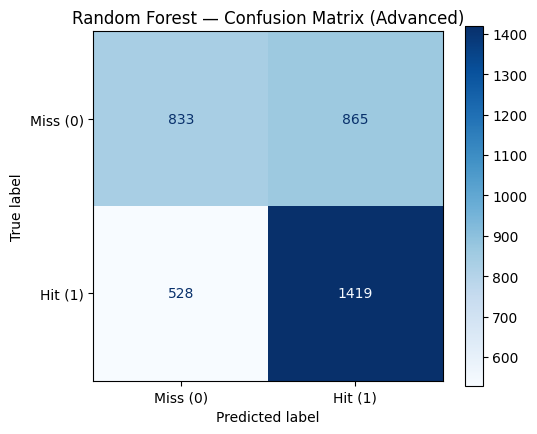

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} — Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 — ROC curve + AUC (Advanced fit)

Generated against `predict_proba` (or `decision_function`
where probabilities aren't available). The AUC is the
ranking-quality summary independent of any threshold choice;
Phase 4's threshold-sweep work depends on it.

Test ROC AUC (Advanced): 0.6591


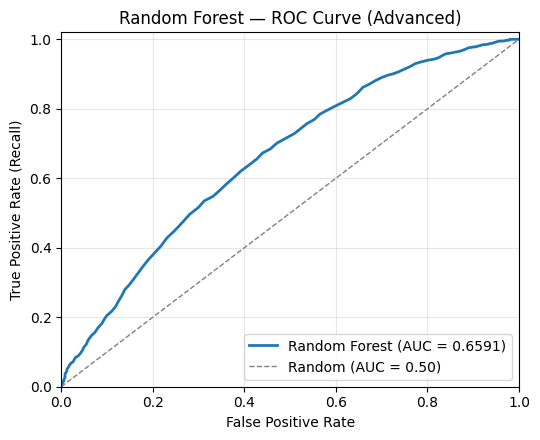

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} — ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 7 — Top-20 feature importances (the inversion story)

The top 7 RF features are **all continuous numerics** —
three engineered (`avg_words_per_step`, `num_ingredients`,
`num_steps`) and four from the original nutrition columns.
This is the **opposite** of the LR coefficient picture
where binary tags dominated. The mechanism: L2 splits
credit among collinear features, but trees pick the single
best splitter per node and are invariant to that
collinearity. See README §3.5.

,importance
avg_words_per_step,0.0499
sodium,0.0433
calories,0.0433
num_ingredients,0.0417
fat,0.0381
protein,0.0354
num_steps,0.0288
bon appétit,0.0099
quick & easy,0.0088
summer,0.0080


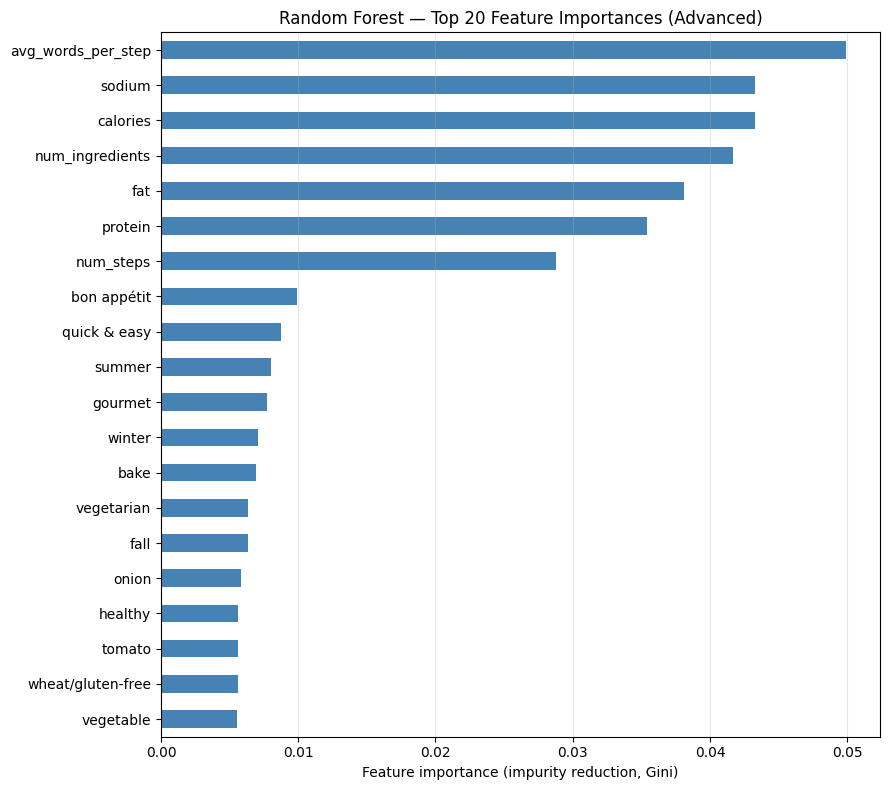

In [7]:
adv_model = per_ds_results["Advanced"]["model"]
X_train_adv = datasets["Advanced"][0]

top = (
    pd.Series(adv_model.feature_importances_, index=X_train_adv.columns)
      .sort_values(ascending=False)
      .head(TOP_K)
)
display(top.round(4).to_frame("importance"))

fig_imp, ax = plt.subplots(figsize=(9, 8))
top.iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Feature importance (impurity reduction, Gini)")
ax.set_title(f"Random Forest — Top {TOP_K} Feature Importances (Advanced)")
ax.grid(axis="x", alpha=0.3)
fig_imp.tight_layout()
save_figure(MODEL_SLUG, "feature_importance.png", fig_imp)
plt.show()

## 8 — Persist the canonical metrics JSON

One JSON per model, written to
`results/<slug>/metrics.json`. Schema is defined in
`src.train_utils.build_metrics_payload`; the master
comparison notebook reads from here.

In [8]:
extras = {
    "top_k_feature_importances": [
        {"feature": str(name), "importance": float(val)}
        for name, val in top.items()
    ],
    "feature_importance_plot": "feature_importance.png",
    "roc_auc_advanced": auc,
}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/random_forest/metrics.json


## 9 — Summary

    **Model:** Random Forest (n=200)

    - **Test Accuracy / F1:** ~0.6178 / ~0.6708 — top scores in the
  whole lineup.
- **Breaks the linear ceiling** by +1.48% Acc, +2.73% F1 vs LR.
- **Inverts the feature-importance ranking** — continuous
  numerics dominate where they were near-zero in LR.

    Run the **master comparison notebook
    (`08_Master_Comparison.ipynb`)** to see this model alongside
    the other six in the side-by-side table.